In [2]:
import os
import warnings
import numpy as np
import xarray as xr
import pandas as pd
import proplot as pplt
from pysr import PySRRegressor
warnings.filterwarnings('ignore')
pplt.rc.update({'figure.dpi':100})

In [3]:
FILEDIR = '/global/cfs/cdirs/m4334/sferrett/monsoon-discovery/data/interim'
x  = xr.open_dataarray(f'{FILEDIR}/cape.nc').isel(time=slice(0,5),lat=slice(0,5),lon=slice(0,5)).values.ravel()
y  = xr.open_dataarray(f'{FILEDIR}/bl.nc').isel(time=slice(0,5),lat=slice(0,5),lon=slice(0,5)).values.ravel()
df = pd.DataFrame({'x':x,'y':y})

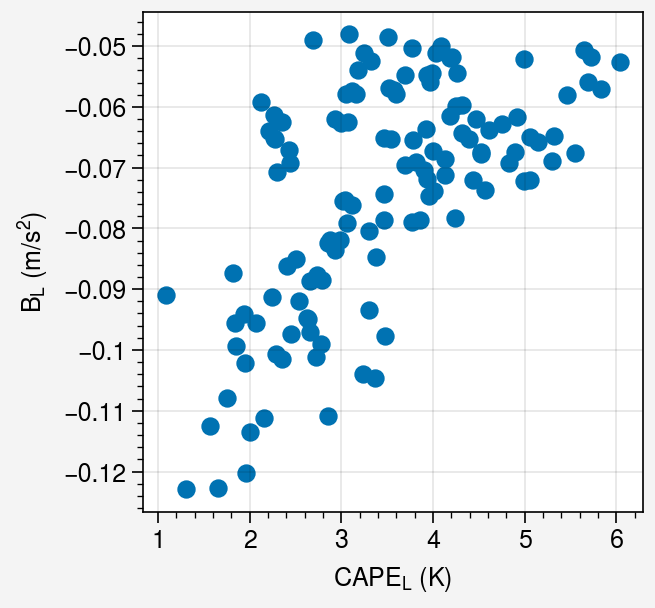

In [4]:
fig,ax = pplt.subplots(nrows=1,ncols=1)
ax.format(xlabel='$CAPE_L$ (K)',ylabel='$B_L$ (m/s$^2$)')
ax.scatter(df['x'],df['y'])
pplt.show()

In [5]:
opcomplexity = {
    '+':1,
    '*':1,
    '-':1,
    '/':3,
    '^':3,
    # 'sin':4,
    # 'cos':4,
    'exp':4,
    'log':4,
    # 'sqrt':4
}

model = PySRRegressor(
    # Search size
    niterations=3, # 500–2000+
    populations=3, # 20–100
    population_size=10, # 50–200
    tournament_selection_n=2, # 5–10
    
    # Operators
    binary_operators=['+','-','*','/','^'], 
    unary_operators=['exp','log'], # sqrt
    
    # Complexity control
    complexity_of_operators=opcomplexity,
    complexity_of_variables=2, # 2–4 (depends on number of variables)
    complexity_of_constants=1, # 1–2
    maxsize=10, # 30–50

    # Critical constraints
    constraints={'^':(-1,1)}, # Maybe (-1,2) if needed, limits arguments of the power operator
    nested_constraints={ # expand only if adding operators
        'exp':{'exp':0,'log':0,'^':0},
        '^':{'^':0},
        'log':{'log':0,'exp':0},
        # 'sqrt':{'sqrt':0,'log':0}
    },  
    
    # Data handling
    batching=False, # True
    batch_size=100, # 500–2000

    # Loss/selection
    loss='loss(x, y) = (x - y)^2',
    model_selection='best',

    # Compute
    random_state=42,
    multithreading=False, # True
    procs=0 # (number of cores - 1)
)

In [ ]:
model.fit(df[['x']].values,df['y'].values)
print(model)

Compiling Julia backend...


In [ ]:
equations = model.equations_
print(equations[['equation','complexity','loss','score']].head(10))

best  = model.get_best()
eqstr = best['sympy_format']
ypred = best['lambda_format'](df[['x']].values)

In [ ]:
fig,ax = pplt.subplots(nrows=1,ncols=1)
ax.format(title='Pareto Frontier of Discovered Equations',
          xlabel='Complexity',xlim=(0.5,8),ylabel='MSE Loss',ylim=(-0.5,14))
ax.scatter(equations['complexity'],equations['loss'])
for i,row in equations.iterrows():
    ax.text(row['complexity']+0.2,row['loss']+0.1,row['equation'])
pplt.show()

fig,ax = pplt.subplots(nrows=1,ncols=1)
ax.format(title=f'Best PySR Equation: {eqstr}',grid=True,xlabel='$y_{true}$',ylabel='$y_{pred}$')
ax.plot(df['y'],df['y'],color='k',linestyle='--')
ax.scatter(df['y'],ypred,alpha=0.6)
pplt.show()

In [ ]:
from pysr import PySRRegressor
import numpy as np
import xarray as xr
import os
from data_loader_helper import *


"""
Notes: 

- !!Be sure to experiment with large populations and niterations (O(1000)?) early, as equations from smaller experiments don't always reflect larger runs with the same hyperparameters/settings - 
new "regimes" sometimes emerge. This includes new variables appearing as important (in place of others earlier in the run) or complicated expressions with many variables replaced by more nonlinear functions of fewer vars.

- exp() or more nonlinear operators (higher powers) require more constraints, and often nested constraints (i.e. "exp": {"exp": 0} ). In some cases, multiple nested (i.e. "exp": {"exp": {"exp": 0} ...})
Functions like x1^x2 and x1*exp(x2^x3) can be dealt with by adjusting the nested_constraints (note this is more precise than using the "complexity_of_operators" parameter, which tends to get rid of certain operators altogether). 
Adjusting `complexity_of_variables` parameter can also help address these issues (especially when the power operator relies on multiple variables). 

Arguments in the power operator tend to become complicated, the constraint `constraints={"^": (-1, 1)}` helps limits the complexity of the power argument (you can experiment with more complex args `constraints={"^": (-1, 2)}). 

- The ratio complexity_of_variables/complexity_of_constants also is important (not just each individually) 
Using complexity_of_variables = 1 (or too small) leads to complicated combinations of variables early on [often with the power operator, such as x_1^(x2*x3)].

- Note the best `complexity_of_variables` value will likely depend on number of variables (chosen for 8 input variables in this example)

- The native PySR `select_k_features` parameter didn't work well for me. 
For reducing number of variables in the final equations, increasing the complexity of variables + doing very large runs can help identify which variables are important.

- Batching is critical to make datasets of size > ~O(10^4) manageable. Compute is generally better spent on longer runs (with smaller batches) vs shorter runs with no batching (and more data points). 

- refer to : https://astroautomata.com/PySR/tuning/, although note some functionality mentioned is outdated or no longer supported



- experiment with different variable scalings. E.g. z-scoring a strictly positive variable x1 might get rid of any x1^a where a<1. In theory and depending on the complexity settings, the algorithm should recover (x1+offset)^a but in practice it doesn't always and so scaling choices can change the form and performance of the equations

- see https://ai.damtp.cam.ac.uk/pysr/api/ for the many options in PySRRegressor


"""

data_path = "../normalized_training_nearest_neig_particle_i6_m31_exp51.nc"

X_vars = ["mix_len_pi1", "mix_len_pi2", "mix_len_pi3", "tke", "bgrad", "strain", "z_obu", "res_obu"]
sym_reg_names = ["pi_1", "pi_2", "pi_3", "tke", 'bgrad', "strain", "z_obu",'res_obu']


y_var = "lmix"
X, Y = load_and_process_data(data_path, X_vars, y_var, N_samples=None)

outputs_dir = 'pysr_outputs' # optional directory for outputs (pysr creates a folder within this for each run)
os.makedirs(outputs_dir, exist_ok=True)


print("Started")
model = PySRRegressor(
    niterations=2000,
    binary_operators=["+", "-", "*", "/", "^"],
    unary_operators=[ "exp", "log", "abs", "neg", "sqrt"], #, "tan", "tanh", "cosh", "erf", "log10", "abs", "erf", "cube", "square", "cos", "sin", 
    populations = 80,
    procs = 29,
    maxsize = 50,
    # complexity_of_operators={
    #      "-": 5,
    # },
    turbo = True,
    complexity_of_variables = 2,
    complexity_of_constants = 1,
    nested_constraints= {"exp": {"exp": 0, "^": 0, "log": 0}, # careful to keep keys unique
                        "^": {"^": 0},
                        "sqrt": {"sqrt": 0, "log": 0},
                        "inv": {"inv": 0,},
                        "log": {"exp": 0, "log":0}},
    constraints={"^": (-1, 1)},
    batching = True,
    batch_size = 1000,
    output_directory=outputs_dir # optional, a folder with the timestamp gets created in this directory for each run
    )

    # select_k_features=3,
    # cluster_manager="slurm",
    # tempdir=tempdir,
    # progress = False,
    # ncyclesperiteration = 1000,
    # temp_equation_file=True,
    # delete_tempfiles=False,
    #     "cos": 3, 
    #     "cube": 3,
    #     "sin": 3,
    #     "square": 3,
    #     "-": 2,
    #     "pow": 3,
    # },
    # extra_sympy_mappings={"inv": lambda x: 1 / x},
    # extra_sympy_mappings={"pow": "x^c"},
    # extra_sympy_mappings={"^": lambda x: x**c},
    # complexity_of_variables = 2,
    # loss="loss(prediction, target) = (prediction - target)^2",
    # optimizer_algorithm="BFGS",
    # model_selection = "best", # "accuracy ""



# test 
# X = 2 * np.random.randn(500, 2) + 10
# y = 2.5382 * (X[:, 1]**(2.5))


model.fit(X, Y, variable_names= sym_reg_names)
print(model)